In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
climate = pd.read_csv(r"C:\Users\wasae\aeroponics-ml\data\raw\GreenhouseClimate.csv")
resources = pd.read_csv(r"C:\Users\wasae\aeroponics-ml\data\raw\Resources.csv")

C:\Users\wasae\AppData\Local\Temp\ipykernel_18636\3021552995.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,14,15,17,18,20,22,23,25,27,29,31,33,35,37,39,41,43,44,45,47,49) have mixed types. Specify dtype option on import or set low_memory=False.
  climate = pd.read_csv(r"C:\Users\wasae\aeroponics-ml\data\raw\GreenhouseClimate.csv")


In [97]:
climate.head()

,%time,AssimLight,BlackScr,CO2air,Cum_irr,EC_drain_PC,EnScr,HumDef,PipeGrow,PipeLow,...,t_rail_min_sp,t_rail_min_vip,t_vent_sp,t_ventlee_vip,t_ventwind_vip,water_sup,water_sup_intervals_sp_min,water_sup_intervals_vip_min,window_pos_lee_sp,window_pos_lee_vip
0,43815.00000,100,35,509,31.6,0.3,96,8.8,0.0,49.9,...,NaN,0.0,NaN,25.0,26.0,263.0,NaN,10,NaN,1.2
1,43815.00347,100,85,484,31.8,0.3,96,9.2,0.0,48.5,...,NaN,0.0,NaN,25.0,26.0,265.0,NaN,10,NaN,1.2
2,43815.00694,100,96,475,31.8,0.3,96,9.1,0.0,46.8,...,NaN,0.0,NaN,25.0,26.0,265.0,NaN,10,NaN,1.2
3,43815.01042,100,96,501,32.0,0.3,96,8.5,0.0,45.2,...,NaN,0.0,NaN,25.0,26.0,267.0,NaN,10,NaN,1.2
4,43815.01389,100,96,487,32.0,0.3,96,8.5,0.0,43.8,...,NaN,0.0,NaN,25.0,26.0,267.0,NaN,10,NaN,1.2


In [98]:
resources.head()

,%Time,Heat_cons,ElecHigh,ElecLow,CO2_cons,Irr,Drain
0,43815,2.8557,0.844750,0.000000,0.005477,16.2,0.0
1,43816,1.1328,0.522667,0.000000,0.005503,0.0,0.0
2,43817,1.1430,0.837000,0.000000,0.011452,0.0,0.0
3,43818,0.1194,0.864000,0.540000,0.019830,0.0,0.0
4,43819,0.5727,1.326583,0.550833,0.031044,0.8,0.0


In [99]:
print(climate.columns)
print(resources.columns)

Index(['%time', 'AssimLight', 'BlackScr', 'CO2air', 'Cum_irr', 'EC_drain_PC',
       'EnScr', 'HumDef', 'PipeGrow', 'PipeLow', 'Rhair', 'Tair', 'Tot_PAR',
       'Tot_PAR_Lamps', 'VentLee', 'Ventwind', 'assim_sp', 'assim_vip',
       'co2_dos', 'co2_sp', 'co2_vip', 'dx_sp', 'dx_vip', 'int_blue_sp',
       'int_blue_vip', 'int_farred_sp', 'int_farred_vip', 'int_red_sp',
       'int_red_vip', 'int_white_sp', 'int_white_vip', 'pH_drain_PC',
       'scr_blck_sp', 'scr_blck_vip', 'scr_enrg_sp', 'scr_enrg_vip',
       't_grow_min_sp', 't_grow_min_vip', 't_heat_sp', 't_heat_vip',
       't_rail_min_sp', 't_rail_min_vip', 't_vent_sp', 't_ventlee_vip',
       't_ventwind_vip', 'water_sup', 'water_sup_intervals_sp_min',
       'water_sup_intervals_vip_min', 'window_pos_lee_sp',
       'window_pos_lee_vip'],
      dtype='object')
Index(['%Time ', 'Heat_cons', 'ElecHigh', 'ElecLow', 'CO2_cons', 'Irr',
       'Drain'],
      dtype='object')


In [100]:
climate = climate.rename(columns={"%time": "Time"})
resources = resources.rename(columns={"%Time ": "Time"})

In [101]:
climate["Time"].head(10)



0    43815.00000
1    43815.00347
2    43815.00694
3    43815.01042
4    43815.01389
5    43815.01736
6    43815.02083
7    43815.02431
8    43815.02778
9    43815.03125
Name: Time, dtype: float64

In [102]:
climate["Time"] = pd.to_datetime(climate["Time"], unit="s")
resources["Time"] = pd.to_datetime(resources["Time"], unit="s")

In [103]:
climate["Time"].max()

Timestamp('1970-01-01 12:13:01')

In [104]:
climate_features = [
    "Tair",
    "Rhair",
    "CO2air",
    "Cum_irr",
    "EC_drain_PC",
    "pH_drain_PC",
    "water_sup"
]

climate2 = climate[climate_features]
resources2 = resources[["Drain"]]


In [105]:
climate2.head()

,Tair,Rhair,CO2air,Cum_irr,EC_drain_PC,pH_drain_PC,water_sup
0,21.0,51.9,509,31.6,0.3,6.5,263.0
1,21.5,51.3,484,31.8,0.3,6.5,265.0
2,21.6,52.2,475,31.8,0.3,6.5,265.0
3,21.3,54.6,501,32.0,0.3,6.5,267.0
4,21.4,54.4,487,32.0,0.3,6.5,267.0


In [106]:
resources2.head()

,Drain
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [107]:
climate2.isna().sum(), resources2.isna().sum()

(Tair           0
 Rhair          0
 CO2air         0
 Cum_irr        0
 EC_drain_PC    0
 pH_drain_PC    0
 water_sup      0
 dtype: int64,
 Drain    0
 dtype: int64)

In [108]:
climate2.dtypes, resources2.dtypes

(Tair           object
 Rhair          object
 CO2air         object
 Cum_irr        object
 EC_drain_PC    object
 pH_drain_PC    object
 water_sup      object
 dtype: object,
 Drain    float64
 dtype: object)

In [109]:
cols_to_numeric = [
    "Tair",
    "Rhair",
    "CO2air",
    "Cum_irr",
    "EC_drain_PC",
    "pH_drain_PC",
    "water_sup"
]

for col in cols_to_numeric:
    climate2[col] = pd.to_numeric(climate2[col], errors="coerce")


C:\Users\wasae\AppData\Local\Temp\ipykernel_18636\3157602555.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  climate2[col] = pd.to_numeric(climate2[col], errors="coerce")


In [110]:
climate2.dtypes

Tair           float64
Rhair          float64
CO2air         float64
Cum_irr        float64
EC_drain_PC    float64
pH_drain_PC    float64
water_sup      float64
dtype: object

In [111]:
climate2[cols_to_numeric].isna().sum()


Tair           71
Rhair          71
CO2air         71
Cum_irr        71
EC_drain_PC    71
pH_drain_PC    71
water_sup      71
dtype: int64

In [112]:
df= pd.concat([climate2,resources2], axis=1)

In [115]:
df.head()

,Tair,Rhair,CO2air,Cum_irr,EC_drain_PC,pH_drain_PC,water_sup,Drain
0,21.0,51.9,509.0,31.6,0.3,6.5,263.0,0.0
1,21.5,51.3,484.0,31.8,0.3,6.5,265.0,0.0
2,21.6,52.2,475.0,31.8,0.3,6.5,265.0,0.0
3,21.3,54.6,501.0,32.0,0.3,6.5,267.0,0.0
4,21.4,54.4,487.0,32.0,0.3,6.5,267.0,0.0


In [116]:
df.isna().sum()

Tair              71
Rhair             71
CO2air            71
Cum_irr           71
EC_drain_PC       71
pH_drain_PC       71
water_sup         71
Drain          47643
dtype: int64

In [117]:
df = df.dropna()


In [118]:
df.isna().sum()

Tair           0
Rhair          0
CO2air         0
Cum_irr        0
EC_drain_PC    0
pH_drain_PC    0
water_sup      0
Drain          0
dtype: int64

In [120]:
df.to_csv(r"C:\Users\wasae\aeroponics-ml\data\processed\finaldataset.csv", index=False)


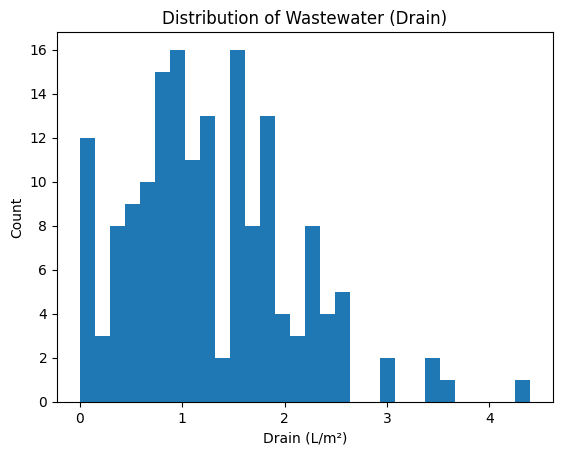

In [123]:
plt.hist(df["Drain"], bins=30)
plt.title("Distribution of Wastewater (Drain)")
plt.xlabel("Drain (L/m²)")
plt.ylabel("Count")
plt.show()

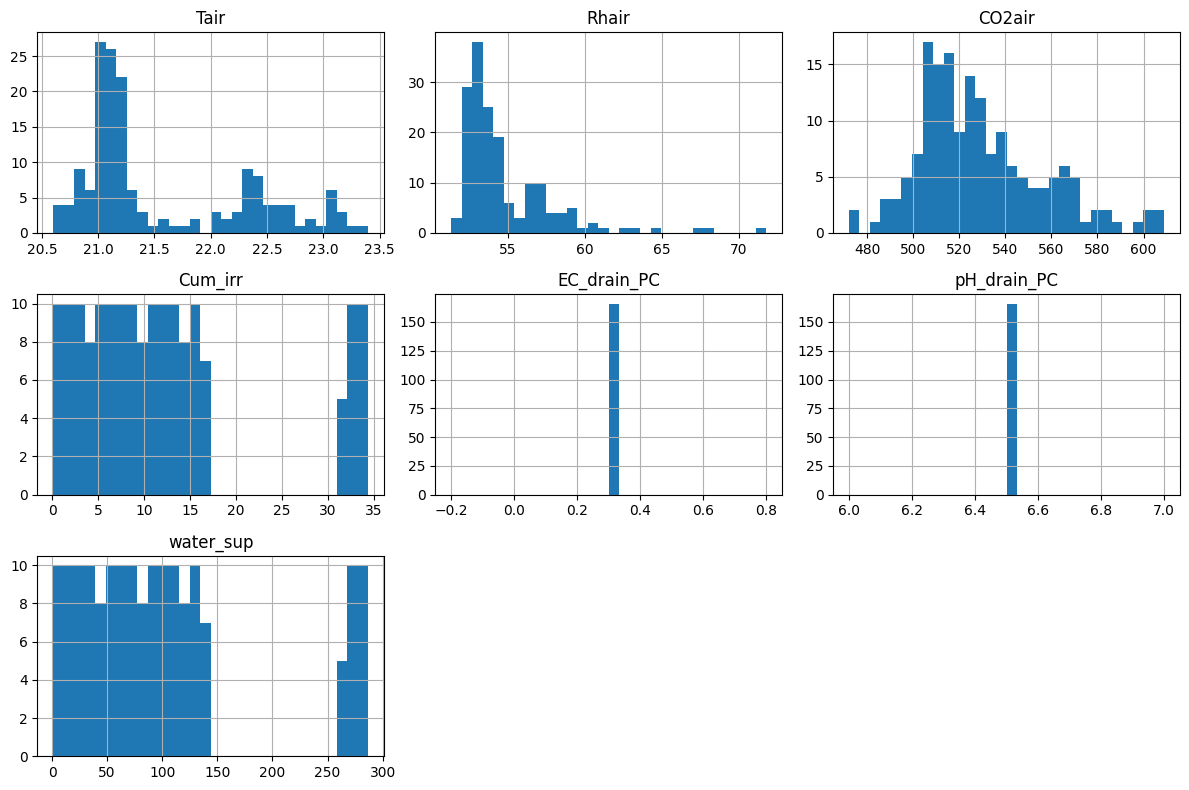

In [124]:
df.drop(columns=["Drain"]).hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

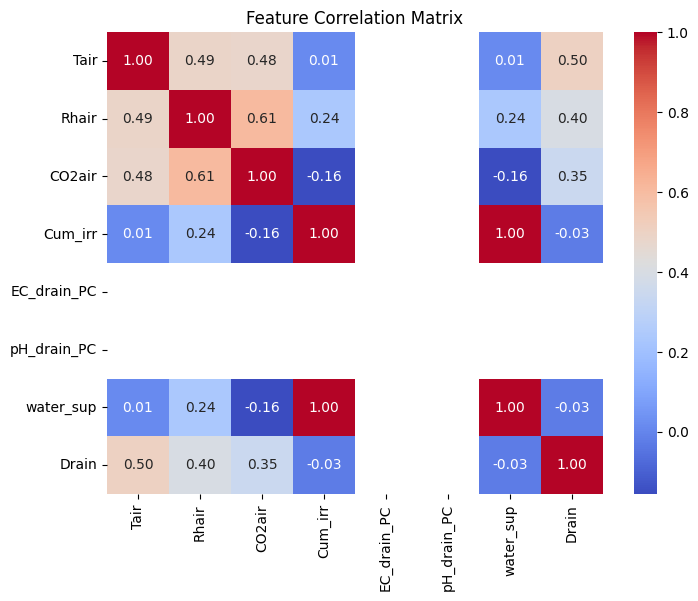

In [126]:

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()
